In [29]:
# imports
# %pip install ipywidgets
# %pip install torch transformers scikit-learn pandas matplotlib seaborn tqdm
# %pip install optuna

# Standard libraries
import os, re, json, pickle, warnings
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils.rnn import pad_sequence

# Transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification

# ML utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
# ask i need this
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.metrics import ConfusionMatrixDisplay

# misc
from tqdm import tqdm
import optuna
from collections import Counter

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Step 1: Data Collection & Preprocessing (MovieWorkflowManager)

In [20]:
# includes data processing, EDA functions, etc. 

class MovieWorkflowManager:
    def __init__(self, metadata_csv_path):
        self.base_path = os.getcwd() 
        self.folders = {
            "audience-reviews-rt":      {"type": "audience", "platform": "rt"},
            "critic-reviews-rt":        {"type": "critic",   "platform": "rt"},
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            "critic-reviews-metacritic": {"type": "critic",   "platform": "metacritic"}
        }
        self.stats = {"scraped_files": 0, "dropped_no_finance": 0, "final_movies": 0}

        self.master_meta = self._load_external_metadata(metadata_csv_path)

    def clean_val(self, v):
        if pd.isna(v) or v == "N/A": return np.nan
        v_str = str(v).strip()
        s = re.sub(r'[^\d.]', '', v_str)
        return float(s) if s else np.nan

    def slugify(self, text):
        if pd.isna(text): return ""
        name = os.path.splitext(str(text))[0].lower()
        for term in ["reviews", "imdb", "rt", "roger", "ebert", "metadata", "audience", "critic"]:
            name = name.replace(term, "")
        
        name = name.replace(" ", "_").replace("-", "_")
        name = re.sub(r'_+', '_', name) 
        return name.strip("_")

    def _load_external_metadata(self, path):
        print(f"Loading metadata from: {path}")
        df = pd.read_csv(path)
        
        df.columns = [c.lower().strip() for c in df.columns]
        
        if 'movie_key' in df.columns:
            df['movie_key_clean'] = df['movie_key'].apply(self.slugify)
        else:
            df['movie_key_clean'] = df['title'].apply(self.slugify)
            
        df['budget_num'] = df['budget'].apply(self.clean_val)
        df['gross_num'] = df['gross_us'].apply(self.clean_val)
        
        df = df.dropna(subset=['budget_num', 'gross_num'])
        
        df = df.drop_duplicates(subset=['movie_key_clean'])
        return df.set_index('movie_key_clean')
    
    def standardize_score(self, val, platform):
        if pd.isna(val) or val == "": return np.nan
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        # platform specific
        if platform == "imdb":
            return score / 10.0
        
        if platform == "rt":
            if score > 10:
                return score / 100.0
            if score <= 5: 
                return score / 5.0
            return score / 10.0
            
        return score 

    def run_full_extraction(self):
        all_data = []

        for folder, info in self.folders.items():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path): continue
                
            files = [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f.lower()]
            
            for f in files:
                self.stats["scraped_files"] += 1
                file_key = self.slugify(f)
                
                if file_key in self.master_meta.index:
                    m = self.master_meta.loc[file_key]
                    
                    rdf = pd.read_csv(os.path.join(path, f))
                    rdf.columns = [c.lower().strip() for c in rdf.columns]
                    
                    score_col = next((c for c in ['user_rating', 'score', 'rating', 'stars', 'user rating'] if c in rdf.columns), None)
                    
                    rdf['user_rating'] = rdf[score_col].apply(lambda x: self.standardize_score(x, info['platform'])) if score_col else np.nan
                    rdf['movie_title'] = file_key
                    rdf['budget'] = m['budget_num']
                    rdf['gross'] = m['gross_num']
                    rdf['year'] = m['year']
                    rdf['is_critic'] = 1 if info['type'] == "critic" else 0
                    all_data.append(rdf)
                else:
                    self.stats["dropped_no_finance"] += 1
        
        if not all_data:
            print("No matching reviews found. Check if your CSV movie_keys match your review filenames.")
            return pd.DataFrame()

        full_df = pd.concat(all_data, ignore_index=True)

        full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)
        self.stats["final_movies"] = full_df['movie_title'].nunique()
        return full_df

    def run_eda_visuals(self, df):
        print("Exploratory Data Analysis")

        print(f"Total Review Files Scraped (multiple reviews per movie): {self.stats['scraped_files']}")
        print(f"Files Dropped (no budget info): {self.stats['dropped_no_finance']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")
        
        # plot 1: survival bar chart
        plt.figure(figsize=(8, 5))
        survival_data = {
            "Stage": ["Files Scraped", "Movies with Financials"],
            "Count": [self.stats['scraped_files'], self.stats['final_movies']]
        }
        sns.barplot(x="Stage", y="Count", data=survival_data, palette="viridis")
        plt.title("Data Pipeline: Scraped vs. Valid Financials")
        plt.ylabel("Number of Movies")
        plt.show()

        # plot 2: audience vs. critic alignment
        corr_data = df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()
        
        # 0 = Audience, 1 = Critic
        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            if not corr_plot_data.empty:
                plt.figure(figsize=(7, 7))
                sns.regplot(x=corr_plot_data[0], y=corr_plot_data[1], 
                            scatter_kws={'alpha':0.4, 'color':'teal'}, 
                            line_kws={'color':'red'})
                plt.xlabel("Avg Audience Rating (Normalized)")
                plt.ylabel("Avg Critic Rating (Normalized)")
                plt.title("Psychological Alignment: Audience vs. Critics")
                
                r_val = corr_plot_data[0].corr(corr_plot_data[1])
                plt.annotate(f'Pearson r = {r_val:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
                plt.show()
            else:
                print("Note: No movies found with both Audience and Critic ratings for correlation plot.")
        else:
            print(f"Note: Only one rating group found. Types found: {corr_data.columns.tolist()}")
    
        # plot 3: distribution of hits vs. flops 
        plt.figure(figsize=(8, 5))
        unique_movie_labels = df.drop_duplicates('movie_title')['label']
        label_counts = unique_movie_labels.value_counts().rename({0: "Flop (<3x)", 1: "Hit (>=3x)"})
        
        sns.barplot(x=label_counts.index, y=label_counts.values, palette="magma")
        plt.title("Target Distribution: Financial Hits vs. Flops")
        plt.xlabel("Success Level")
        plt.ylabel("Number of Unique Movies")
        
        total = len(unique_movie_labels)
        for i, v in enumerate(label_counts.values):
            plt.text(i, v + (total*0.01), f"{(v/total)*100:.1f}%", ha='center', fontweight='bold')
        plt.show()

    def generate_trials(self, df):
        clean_df = df.dropna(subset=['review_text']).copy()

        trial_a = clean_df.copy()
        
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget': 'first',
            'year': 'first',
            'label': 'first',
            'user_rating': 'mean',
            'is_critic': 'mean'
        }).reset_index()
        
        return trial_a, trial_b
    
    def compare_trials_initially(self, t_a, t_b):
        feats   = ['user_rating', 'year']
        trials  = [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]
        results = {}

        for name, df in trials:

            existing_feats = [f for f in feats if f in df.columns]
            temp_df = df.dropna(subset=existing_feats + ['label'])

            if len(temp_df) == 0:
                print(f"Skipping {name} — No valid rows.")
                continue

            X = temp_df[existing_feats]
            y = temp_df['label']

            gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            preds      = rf.predict(X_test)
            proba      = rf.predict_proba(X_test)[:, 1]
            
            results[name] = {
                "Accuracy": accuracy_score(y_test, preds),
                "F1-Score": f1_score(y_test, preds, average='weighted'),
                "cm": confusion_matrix(y_test, preds),
                "auc": auc(*roc_curve(y_test, proba)[:2]),
                "fpr": roc_curve(y_test, proba)[0],
                "tpr": roc_curve(y_test, proba)[1],
                "df_full": temp_df
            }
            
            print(f"{name} -> Acc: {results[name]['Accuracy']:.3f}, F1: {results[name]['F1-Score']:.3f}")

        # visualization
        self._plot_trial_comparison(results)
        
        winner = max(results, key=lambda n: results[n]["F1-Score"])
        print(f"\nConclusion: {winner} is the more predictive structure for this dataset.")
        return winner

    def _plot_trial_comparison(self, results):
        names = list(results.keys())
        colors = {"Trial A (Individual)": "#2ecc71", "Trial B (Collective)": "#e74c3c"}

        # 1. side by side 
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(names))
        width = 0.35
        
        accs = [results[n]["Accuracy"] for n in names]
        f1s = [results[n]["F1-Score"] for n in names]
        
        ax.bar(x - width/2, accs, width, label='Accuracy', color='skyblue')
        ax.bar(x + width/2, f1s, width, label='F1-Score', color='salmon')
        
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.set_ylim(0, 1.1)
        ax.set_title("Trial Comparison: Baseline Performance (Tabular Data Only)")
        ax.legend()
        plt.show()

        # 2. confusion matrices
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        economic_labels = [["True Neg", "False Pos"], 
                           ["False Neg", "True Pos"]]

        for ax, name in zip(axes, names):
            cm = results[name]["cm"]
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f"Confusion Matrix: {name}")
            ax.set_xticklabels(['Pred Flop', 'Pred Hit'])
            ax.set_yticklabels(['Actual Flop', 'Actual Hit'])
            
            for i in range(2):
                for j in range(2):
                    ax.text(j + 0.5, i + 0.8, economic_labels[i][j], 
                            ha='center', va='center', color='darkred', fontsize=8)
        plt.tight_layout()
        plt.show()
        
# data loader for model  -> is this something else , should it go into bert
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tok
    
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "ids": e["input_ids"].squeeze(0), 
            "mask": e["attention_mask"].squeeze(0), 
            "num": self.numeric[i], 
            "lab": self.labels[i]
        }

# economic confusion matrix 
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (1,1):
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative", "False Positive"],
        ["False Negative", "True Positive"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()

Loading metadata from: movie_metadata.csv
Exploratory Data Analysis
Total Review Files Scraped (multiple reviews per movie): 942
Files Dropped (no budget info): 218
Final Unique Movies in Study: 202


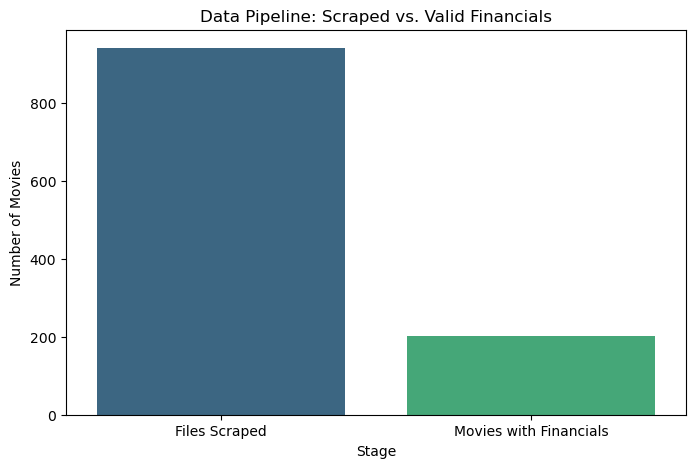

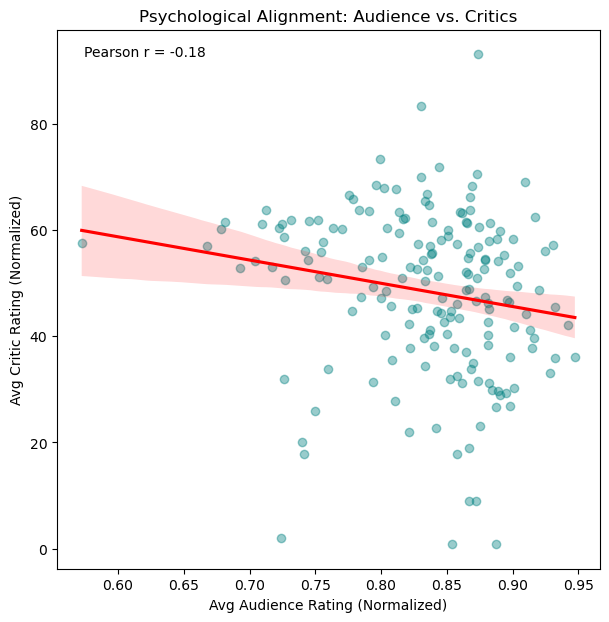

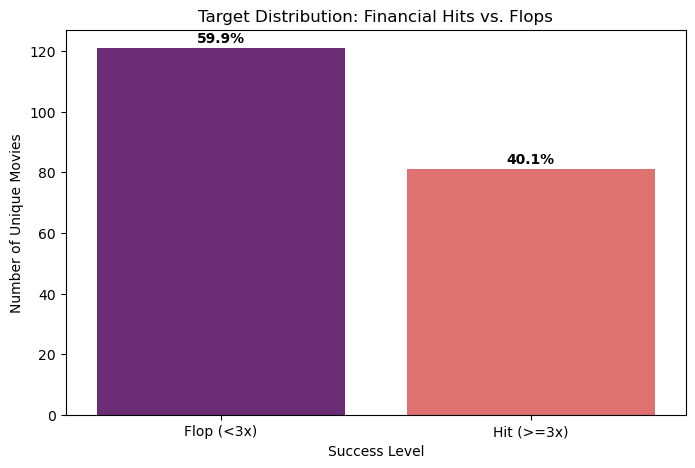

In [21]:
# execution 

# intialize and extract 
path_to_your_csv = "movie_metadata.csv"
manager = MovieWorkflowManager(path_to_your_csv)
full_dataset = manager.run_full_extraction()
manager.run_eda_visuals(full_dataset)

## Step 2: Individual vs. Collective Opinion (Trial A vs. B)

Trial A (Individual) -> Acc: 0.457, F1: 0.448
Trial B (Collective) -> Acc: 0.607, F1: 0.584


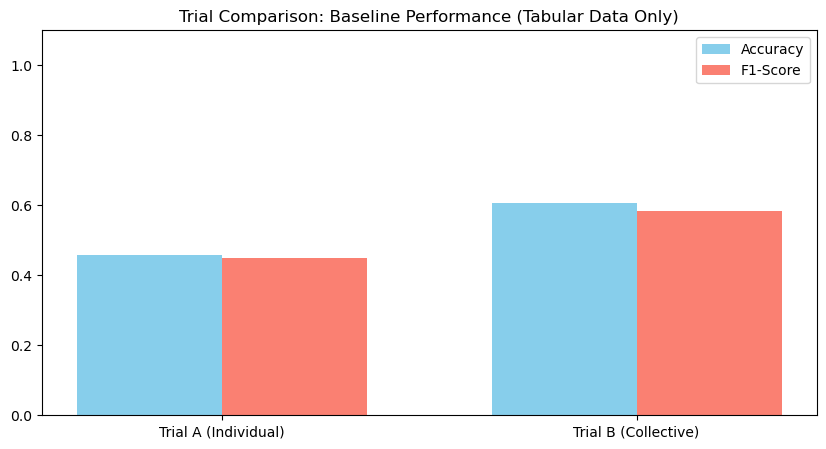

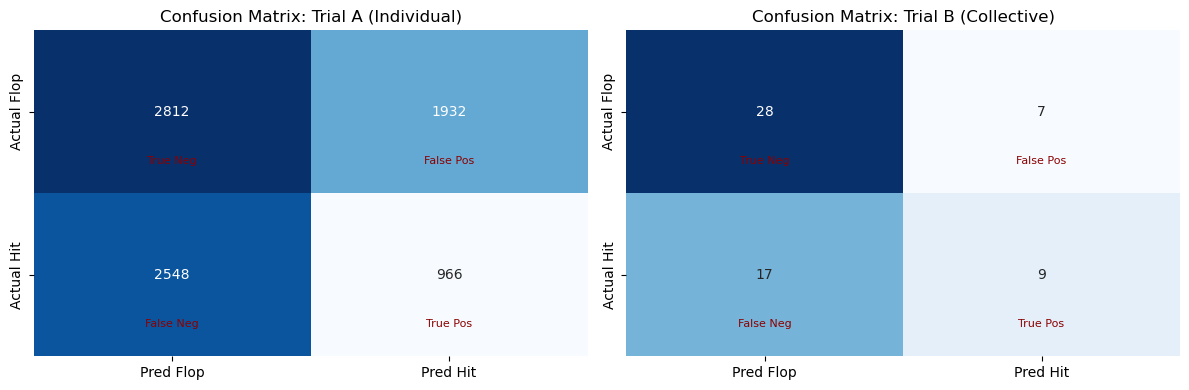


Conclusion: Trial B (Collective) is the more predictive structure for this dataset.


In [22]:
# generate trials
trial_a, trial_b = manager.generate_trials(full_dataset)
winning_trial_name = manager.compare_trials_initially(trial_a, trial_b)

In [23]:
# Select Trial B for training volume
df_final = trial_b

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_final, groups=df_final['movie_title']))
train_df, test_df = df_final.iloc[train_idx].copy(), df_final.iloc[test_idx].copy()

numeric_feats = ['user_rating', 'budget']

## Step 3: Training Models

### Model 1: Random Forest (Numeric only)

Running Model 1: Random Forest...
Model 1 - Random Forest F1-Score: 0.439



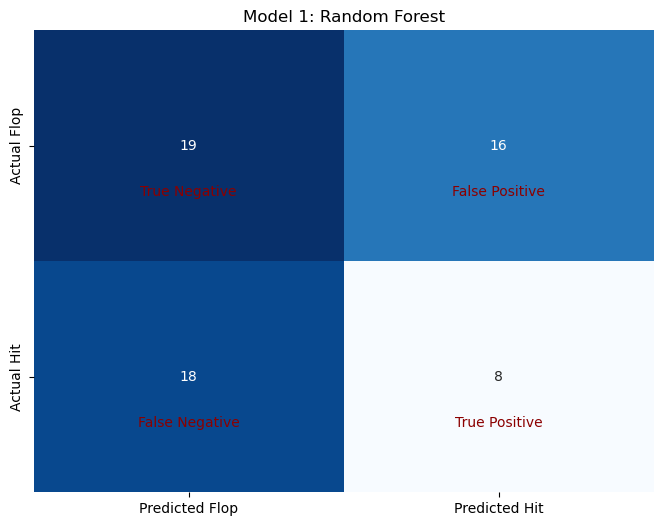

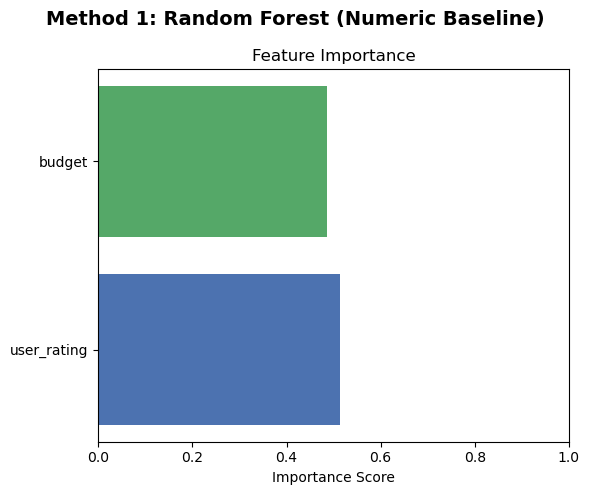

In [24]:
# model 1: random forest (numeric baseline)
print("Running Model 1: Random Forest...")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_num, train_df['label'])

m1_preds = rf_model.predict(X_test_num)
m1_f1 = f1_score(test_df['label'], m1_preds, average='weighted')

print(f"Model 1 - Random Forest F1-Score: {m1_f1:.3f}\n")
plot_economic_matrix(test_df['label'], m1_preds, "Model 1: Random Forest")

# Change subplots to 1x1 and adjust figsize (height reduced from 10 to 5)
fig, ax = plt.subplots(figsize=(6, 5)) 
fig.suptitle("Method 1: Random Forest (Numeric Baseline)", fontsize=14, fontweight='bold')

# Feature importance 
importances = rf_model.feature_importances_

# Use 'ax' directly instead of 'axes[1]'
ax.barh(numeric_feats, importances, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Model 2: BERT (Text only)

Using device for BERT: mps
Running Model 2: BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


Epoch 1: 100%|██████████| 18/18 [00:30<00:00,  1.68s/it]


Epoch 1 average loss: 0.6854


Epoch 2: 100%|██████████| 18/18 [00:21<00:00,  1.17s/it]


Epoch 2 average loss: 0.6682
Evaluating...


Testing: 100%|██████████| 8/8 [00:06<00:00,  1.29it/s]


Method 2 - BERT F1-Score: 0.418


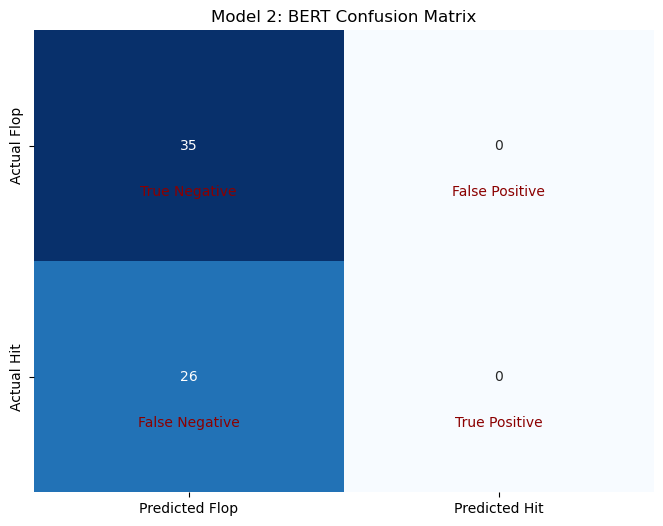

In [ ]:
# model 2: bert (qualitative baseline)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        encoding = self.tokenizer(self.texts[i], truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

# set device 
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): 
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device for BERT: {device}")

# weights 
weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# start
print("Running Model 2: BERT...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
m2_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# freeze all layers except top 2 -> 12
for name, param in m2_model.bert.named_parameters():
    if "encoder.layer.11" not in name and "encoder.layer.10" not in name:
        param.requires_grad = False

# prepare data loaders
train_ds = SimpleTextDataset(train_df['review_text'].tolist(), train_df['label'].tolist(), tokenizer)
test_ds = SimpleTextDataset(test_df['review_text'].tolist(), test_df['label'].tolist(), tokenizer)

train_loader_m2 = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader_m2 = DataLoader(test_ds, batch_size=8)

# optimizer
criterion_m2 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_m2 = AdamW(filter(lambda p: p.requires_grad, m2_model.parameters()), lr=2e-5)

# training loop
print("Starting training...")
m2_model.train()
for epoch in range(3): 
    for batch in tqdm(train_loader_m2):
        optimizer_m2.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = m2_model(input_ids, attention_mask=attention_mask)
        loss = criterion_m2(outputs.logits, labels)
        
        loss.backward()
        optimizer_m2.step()
    
# evaluation 
print("Evaluating...")
m2_model.eval()
m2_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader_m2, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = m2_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        m2_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

m2_f1 = f1_score(test_df['label'], m2_preds, average='weighted')
print(f"\nMethod 2 - BERT F1-Score: {m2_f1:.3f}")
plot_economic_matrix(test_df['label'], m2_preds, "Model 2: BERT Confusion Matrix")

### Model 3 — Hybrid BERT + Numeric

In [36]:
# model 3: hybrid model 

# neural network 
class MovieClassifier(nn.Module):
    def __init__(self, n_dim, hidden_dim, dropout_prob):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for n, p in self.bert.named_parameters():
            if "encoder.layer.10" not in n and "encoder.layer.11" not in n: 
                p.requires_grad = False

        self.num_bnch = nn.Sequential(
            nn.Linear(n_dim, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_prob)
        )

        self.fusion = nn.Sequential(
            nn.Linear(768 + 64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)
    
num_flops = (train_df['label'] == 0).sum()
num_hits = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_flops / num_hits], dtype=torch.float).to(device)

# hyperparameter tuner
def objective(trial, train_df, test_df, numeric_feats):
    lr = trial.suggest_float("lr", 0.0001, 0.001, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    dropout_prob = trial.suggest_float("dropout", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [8, 16])

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[numeric_feats].fillna(0))
    X_test = scaler.transform(test_df[numeric_feats].fillna(0))
    
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    train_loader = DataLoader(MovieDataset(train_df['review_text'].tolist(), X_train, train_df['label'].tolist(), tokenizer), 
                           batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(MovieDataset(test_df['review_text'].tolist(), X_test, test_df['label'].tolist(), tokenizer), 
                          batch_size=batch_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    m3_model_trial = MovieClassifier(len(numeric_feats), hidden_dim, dropout_prob).to(device)
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, m3_model_trial.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    m3_model_trial.train()
    for epoch in range(3): 
        for b in train_loader:
            optimizer.zero_grad()
            out = m3_model_trial(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            loss = criterion(out, b["lab"].to(device))
            loss.backward()
            optimizer.step()

    m3_model_trial.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for b in test_loader:
            logits = m3_model_trial(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            p = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            preds.extend(p)
            actuals.extend(b["lab"].numpy())

    return f1_score(actuals, preds, average='weighted') 

def run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=10):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df, numeric_feats), n_trials=n_trials)

    return study.best_params

print("Running Model 3: Hybrid...")

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# hyperparameter tuning
print("Running hyperparameter tuning...")
best_params_m3 = run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=5)
best_lr = best_params_m3['lr']
best_batch = best_params_m3['batch_size']
best_hidden_dim = best_params_m3['hidden_dim']

# scale numeric data
X_train_m3 = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_m3 = scaler.transform(test_df[numeric_feats].fillna(0))

# prepare data loaders
train_loader_m3 = DataLoader(
    MovieDataset(train_df['review_text'].tolist(), X_train_m3, train_df['label'].tolist(), tokenizer), 
    batch_size=best_batch, 
    shuffle=True
)
test_loader_m3 = DataLoader(
    MovieDataset(test_df['review_text'].tolist(), X_test_m3, test_df['label'].tolist(), tokenizer), 
    batch_size=best_batch
)

# initialize model
m3_model = MovieClassifier(
    n_dim=len(numeric_feats), 
    hidden_dim=best_params_m3['hidden_dim'], 
    dropout_prob=best_params_m3['dropout']
).to(device)
opt = AdamW(filter(lambda p: p.requires_grad, m3_model.parameters()), lr=best_lr)
crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# training loop
m3_model.train()
for ep in range(8):
    total_loss = 0
    for b in train_loader_m3:
        opt.zero_grad()
        out = m3_model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        loss = crit(out, b["lab"].to(device))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {total_loss/len(train_loader_m3):.4f}")

# evaluation
m3_model.eval()
m3_preds = []
with torch.no_grad(): 
    for b in test_loader_m3:
        logits = m3_model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        p = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
        m3_preds.extend(p)

m3_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Model 3 - Hybrid F1-Score: {m3_f1:.3f}")
plot_economic_matrix(test_df['label'], m3_preds, "Model 3: Hybrid Confusion Matrix")

Running Model 3: Hybrid...


[I 2026-03-16 21:22:56,378] A new study created in memory with name: no-name-3e2d0342-3cb7-45d4-b213-2ccec15e93f7


Running hyperparameter tuning...


[I 2026-03-16 21:23:48,858] Trial 0 finished with value: 0.4183743169398907 and parameters: {'lr': 0.0008990282919259668, 'hidden_dim': 128, 'dropout': 0.3331973371435599, 'batch_size': 8}. Best is trial 0 with value: 0.4183743169398907.
[I 2026-03-16 21:24:57,579] Trial 1 finished with value: 0.4106988783433995 and parameters: {'lr': 0.0005136265575869403, 'hidden_dim': 256, 'dropout': 0.4010956107713246, 'batch_size': 16}. Best is trial 0 with value: 0.4183743169398907.
[I 2026-03-16 21:26:02,540] Trial 2 finished with value: 0.39656518345042935 and parameters: {'lr': 0.0002761774139020682, 'hidden_dim': 128, 'dropout': 0.4231538508133957, 'batch_size': 8}. Best is trial 0 with value: 0.4183743169398907.
[I 2026-03-16 21:27:06,549] Trial 3 finished with value: 0.4183743169398907 and parameters: {'lr': 0.0009943188382123983, 'hidden_dim': 256, 'dropout': 0.24408889457988667, 'batch_size': 8}. Best is trial 0 with value: 0.4183743169398907.
[I 2026-03-16 21:28:17,637] Trial 4 finished 

KeyboardInterrupt: 

## Model 4 — BiLSTM (Text Only)

Running Model 4: Bidirectional LSTM
Running hyperparameter tuning:
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.4594
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5512
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.4655
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.3708
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.4937
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.6892
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5269
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5323
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.4740
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.6155
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5574
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.6055
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.4929
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5432
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5747
Testing: LR=0.001, Hidde

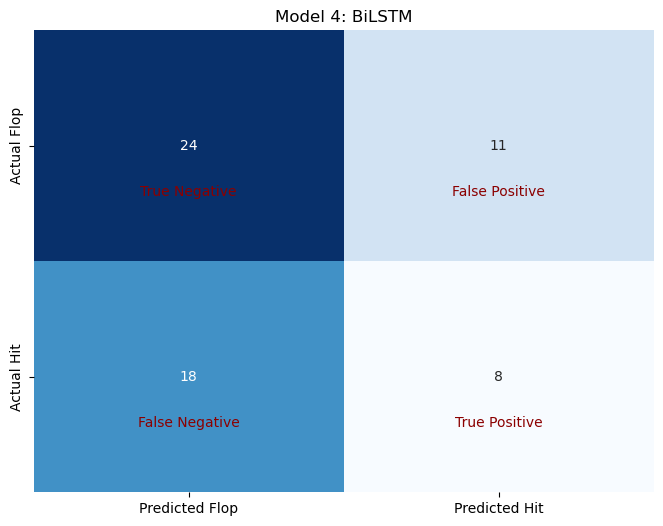

In [ ]:
# model 4: biLSTM 

# functions 
def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)

    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1

    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

# hyperparameter tuner
def tune_lstm(train_indices, train_labels, test_indices, test_labels, vocab, device):
    lrs = [0.001, 0.0005, 0.0001]
    hiddens = [64, 128, 256]
    dropouts = [0.2, 0.5]
    embed_dims = [100, 200, 300]
    
    best_f1 = 0
    best_params = {}

    # what is pad_sequence
    X_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)
    X_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    
    for lr in lrs:
        for hd in hiddens:
            for dr in dropouts:
                for ed in embed_dims:
                    print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}")
                    model = MovieLSTM(len(vocab), ed, hd, dr).to(device) 
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
                    
                    model.train()
                    for epoch in range(5):
                        optimizer.zero_grad()
                        out = model(X_train)
                        loss = criterion(out, y_train)
                        loss.backward()
                        optimizer.step()
                    
                    model.eval()
                    with torch.no_grad():
                        logits = model(X_test)
                        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                        score = f1_score(test_labels, preds, average='weighted')
                    
                    print(f"Result F1: {score:.4f}")
                    if score > best_f1:
                        best_f1 = score
                        best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
    
    return best_params

class MovieLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout_prob=0.3):
        super(MovieLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout_prob) 
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_cat = self.dropout(hidden_cat) 
        return self.fc(hidden_cat).squeeze(1)
    
num_flops = (train_df['label'] == 0).sum()
num_hits = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_flops / num_hits], dtype=torch.float).to(device)

print("Running Model 4: Bidirectional LSTM")

vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

# hyperparameter tuning
print("Running hyperparameter tuning:")
best_params_m4 = tune_lstm(train_indices, train_df['label'], test_indices, test_df['label'], vocab, device)

# data prep
X_train_m4 = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_test_m4 = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
y_train_m4 = torch.tensor(train_df['label'].values, dtype=torch.float32)

# training 
print(f"Training LSTM with: {best_params_m4}")
lstm_model = MovieLSTM(len(vocab), 128, best_params_m4['hidden'], best_params_m4['dropout']).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_params_m4['lr'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

lstm_model.train()
for epoch in range(5): 
    optimizer.zero_grad()
    outputs = lstm_model(X_train_m4.to(device))
    loss = criterion(outputs, y_train_m4.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# evaluation
lstm_model.eval()
with torch.no_grad():
    m4_logits = lstm_model(X_test_m4.to(device))
    m4_preds = (torch.sigmoid(m4_logits) >= 0.5).int().cpu().numpy()

m4_f1 = f1_score(test_df['label'], m4_preds, average='weighted')
print(f"\nModel 4 - BiLSTM F1-Score: {m4_f1:.3f}")
plot_economic_matrix(test_df['label'], m4_preds, "Model 4: BiLSTM")

## Model 5 — Hybrid BiLSTM + Numeric

Running Model 5: Hybrid BiLSTM...
Running hyperparameter tuning...
Testing: LR=0.001, Hidden=64, Dropout=0.2, Embed=100
Result F1: 0.5590
Testing: LR=0.001, Hidden=64, Dropout=0.2, Embed=200
Result F1: 0.4331
Testing: LR=0.001, Hidden=64, Dropout=0.3, Embed=100
Result F1: 0.6192
Testing: LR=0.001, Hidden=64, Dropout=0.3, Embed=200
Result F1: 0.5420
Testing: LR=0.001, Hidden=64, Dropout=0.5, Embed=100
Result F1: 0.3234
Testing: LR=0.001, Hidden=64, Dropout=0.5, Embed=200
Result F1: 0.5093
Testing: LR=0.001, Hidden=128, Dropout=0.2, Embed=100
Result F1: 0.5696
Testing: LR=0.001, Hidden=128, Dropout=0.2, Embed=200
Result F1: 0.4209
Testing: LR=0.001, Hidden=128, Dropout=0.3, Embed=100
Result F1: 0.4703
Testing: LR=0.001, Hidden=128, Dropout=0.3, Embed=200
Result F1: 0.6066
Testing: LR=0.001, Hidden=128, Dropout=0.5, Embed=100
Result F1: 0.5738
Testing: LR=0.001, Hidden=128, Dropout=0.5, Embed=200
Result F1: 0.6413
Testing: LR=0.0005, Hidden=64, Dropout=0.2, Embed=100
Result F1: 0.5109
Tes

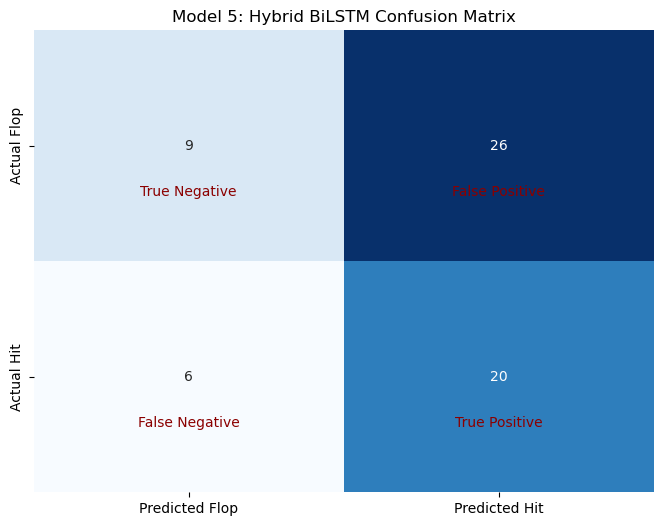

In [ ]:
# model 5: hybrid biLSTM 

import copy
import random

def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)
    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

def tune_hybrid_bilstm(train_indices, train_numeric, train_labels, 
                     test_indices, test_numeric, test_labels, vocab, device):
    lrs = [0.001, 0.0005]
    hiddens = [64, 128]
    dropouts = [0.2, 0.3, 0.5]
    embed_dims = [100,200]

    best_f1 = 0 
    best_params = {}

    X_text_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    X_num_train = torch.tensor(train_numeric, dtype=torch.float32).to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)

    X_text_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    X_num_test = torch.tensor(test_numeric, dtype=torch.float32).to(device)

    for lr in lrs:
            for hd in hiddens:
                for dr in dropouts:
                    for ed in embed_dims:
                        print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}, Embed={ed}")
                        model = HybridBiLSTM(len(vocab), ed, hd, train_numeric.shape[1], dr).to(device) 
                        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
                        
                        model.train()
                        for epoch in range(5):
                            optimizer.zero_grad()

                            out = model(X_text_train, X_num_train)
                            loss = criterion(out, y_train)
                            loss.backward()
                            optimizer.step()
                        
                        model.eval()
                        with torch.no_grad():
                            logits = model(X_text_test, X_num_test)
                            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                            score = f1_score(test_labels, preds, average='weighted')
                        
                        print(f"Result F1: {score:.4f}")
                        if score > best_f1:
                            best_f1 = score
                            best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
        
    return best_params

# neural network 
class HybridBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_numeric_feats, dropout_prob=0.3):
        super(HybridBiLSTM, self).__init__()
        
        # text branch 
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # numeric branch 
        self.num_branch = nn.Sequential(
            nn.Linear(num_numeric_feats, 32),
            nn.ReLU()
        )

        self.dropout = nn.Dropout(dropout_prob)

        # fusion 
        self.fc = nn.Linear((hidden_dim * 2) + 32, 1)
        
    def forward(self, text, numeric):

        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        text_f = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        num_f = self.num_branch(numeric)
        
        combined = torch.cat((text_f, num_f), dim=1)
        combined = self.dropout(combined)
        return self.fc(combined).squeeze(1)

num_flops = (train_df['label'] == 0).sum()
num_hits = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_flops / num_hits], dtype=torch.float).to(device)

print("Running Model 5: Hybrid BiLSTM...")

vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

# hyperparameter tuning
print("Running hyperparameter tuning...")
best_params_m5 = tune_hybrid_bilstm(train_indices, X_train_num, train_df['label'], 
                                  test_indices, X_test_num, test_df['label'], 
                                  vocab, device)

X_text_train_m5 = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_num_train_m5 = torch.tensor(X_train_num, dtype=torch.float32)
y_train_m5 = torch.tensor(train_df['label'].values, dtype=torch.float32)

X_text_test_m5 = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
X_num_test_m5 = torch.tensor(X_test_num, dtype=torch.float32)

# train model
print(f"Training Hybrid LSTM with: {best_params_m5}")
m5_model = HybridBiLSTM(len(vocab), 
                        best_params_m5['embed'], 
                        best_params_m5['hidden'], 
                        len(numeric_feats), 
                        best_params_m5['dropout']).to(device)
optimizer = torch.optim.Adam(m5_model.parameters(), lr=best_params_m5['lr'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# training loop
m5_model.train()
for epoch in range(5): 
    optimizer.zero_grad()

    outputs = m5_model(X_text_train_m5.to(device), X_num_train_m5.to(device))
    loss = criterion(outputs, y_train_m5.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(m5_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# evaluation
m5_model.eval()
with torch.no_grad():
    m5_logits = m5_model(X_text_test_m5.to(device), X_num_test_m5.to(device))
    probs = torch.sigmoid(m5_logits)
    
    m5_preds = (probs >= 0.5).int().cpu().numpy()

m5_f1 = f1_score(test_df['label'], m5_preds, average='weighted')
print(f"Model 5 - Hybrid BiLSTM F1-Score: {m5_f1:.3f}")
plot_economic_matrix(test_df['label'], m5_preds, "Model 5: Hybrid BiLSTM Confusion Matrix")

In [35]:
counts = train_df['label'].value_counts()
print(f"Flops (0): {counts[0]}")
print(f"Hits (1): {counts[1]}")
print(f"Ratio: {counts[0]/counts[1]:.2f} to 1")

Flops (0): 86
Hits (1): 55
Ratio: 1.56 to 1


## Final Model Comparison Chart

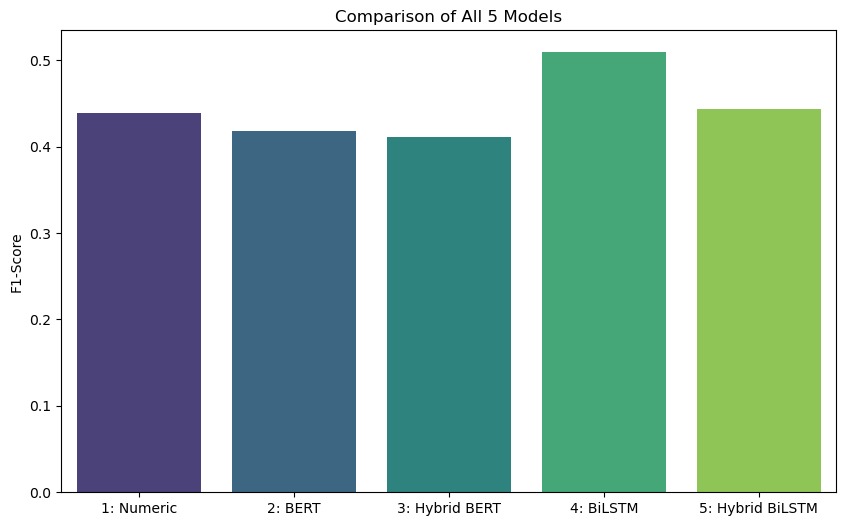

[0.4392167577413479, 0.4183743169398907, 0.4106988783433995, 0.5092233813545288, 0.44335154826958106]


In [ ]:
# model comparison chart
plt.figure(figsize=(10, 6))
methods = ['1: Numeric', '2: BERT', '3: Hybrid BERT', '4: BiLSTM', '5: Hybrid BiLSTM']
scores = [m1_f1, m2_f1, m3_f1, m4_f1, m5_f1]
sns.barplot(x=methods, y=scores, palette="viridis")
plt.title("Comparison of All 5 Models")
plt.ylabel("F1-Score")
plt.show()

## Comparison


Audience vs. Critic Comparison Analysis

Aggregating Audience reviews into Movie-Level profiles...
Result: 177 unique movies found for Audience.
DONE: Audience | RF F1: 0.469 | LSTM F1: 0.574

Aggregating Critics reviews into Movie-Level profiles...
Result: 202 unique movies found for Critics.
DONE: Critics | RF F1: 0.536 | LSTM F1: 0.411


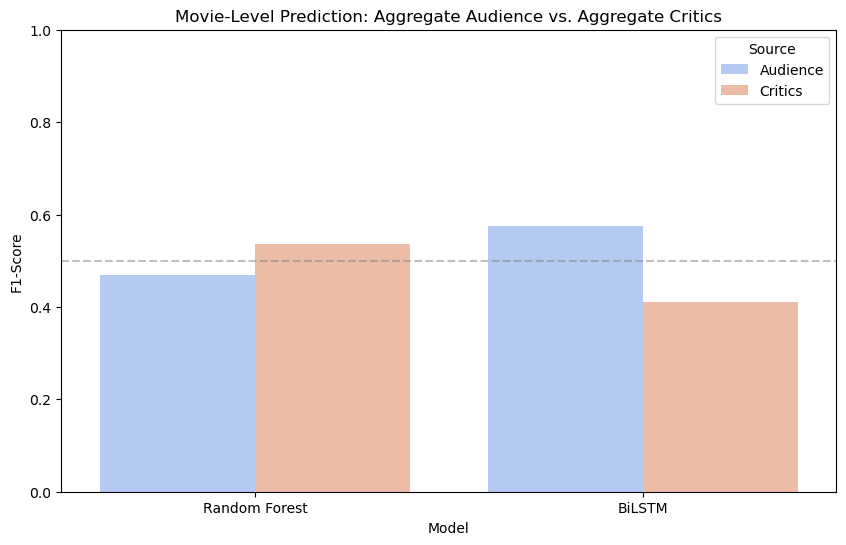

In [40]:
def run_movie_level_comparison(full_df, vocab, device):
    print("\nAudience vs. Critic Comparison Analysis")
    
    cohorts_raw = {
        "Audience": full_df[full_df['is_critic'] == 0].copy(),
        "Critics":   full_df[full_df['is_critic'] == 1].copy()
    }
    
    comparison_data = []

    for name, df_raw in cohorts_raw.items():
        print(f"\nAggregating {name} reviews into Movie-Level profiles...")
        
        movie_level_df = df_raw.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'user_rating': 'mean',
            'year': 'first',
            'label': 'first'
        }).reset_index()

        print(f"Result: {len(movie_level_df)} unique movies found for {name}.")

        # model 1: random forest
        numeric_feats = ['user_rating', 'year']
        X_num = movie_level_df[numeric_feats]
        y_num = movie_level_df['label']
        
        from sklearn.model_selection import train_test_split
        X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
            X_num, y_num, test_size=0.3, random_state=42
        )
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train_n, y_train_n)
        rf_f1 = f1_score(y_test_n, rf.predict(X_test_n), average='weighted')
        comparison_data.append({"Model": "Random Forest", "Source": name, "F1-Score": rf_f1})

        # model 2: BiLSTM
        indices = [torch.tensor(text_to_indices(t, vocab)) for t in movie_level_df['review_text']]
        X_text = pad_sequence(indices, batch_first=True, padding_value=0)[:, :512]
        y_text = torch.tensor(movie_level_df['label'].values, dtype=torch.float32)
        
        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X_text, y_text, test_size=0.3, random_state=42
        )
        
        model = MovieLSTM(len(vocab), embed_dim=128, hidden_dim=128, dropout_prob=0.3).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]).to(device))
        
        model.train()
        for epoch in range(15):
            optimizer.zero_grad()
            out = model(X_train_t.to(device))
            loss = criterion(out, y_train_t.to(device))
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t.to(device))
            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            lstm_f1 = f1_score(y_test_t, preds, average='weighted')
            
        comparison_data.append({"Model": "BiLSTM", "Source": name, "F1-Score": lstm_f1})
        print(f"DONE: {name} | RF F1: {rf_f1:.3f} | LSTM F1: {lstm_f1:.3f}")

    # plot
    res_df = pd.DataFrame(comparison_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res_df, x="Model", y="F1-Score", hue="Source", palette="coolwarm")
    plt.title("Movie-Level Prediction: Aggregate Audience vs. Aggregate Critics", fontsize=12)
    plt.ylim(0, 1.0)
    plt.axhline(0.5, ls='--', color='gray', alpha=0.5)
    plt.show()
    
    return res_df

# execute
final_movie_results = run_movie_level_comparison(full_dataset, global_vocab, device)